# Análisis de resultados experimentales

Este notebook analiza los experimentos ejecutados para Análisis Arquetípico aplicado a curvas de luz de estrellas variables.

In [1]:
# 1. Imports

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()

while ROOT.name != "experimentos":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RESULTS_DIR = ROOT / "resultados"
RESUMEN_CSV = RESULTS_DIR / "resumen_experimentos.csv"

print("ROOT:", ROOT)
print("Resumen:", RESUMEN_CSV)
print("Existe:", RESUMEN_CSV.exists())  

ROOT: C:\Users\adanm\Documentos\Magister en Ciencia de datos (UDLA)\TESIS\experimentos
Resumen: C:\Users\adanm\Documentos\Magister en Ciencia de datos (UDLA)\TESIS\experimentos\resultados\resumen_experimentos.csv
Existe: True


In [3]:
# 3. Cargar CSV
df = pd.read_csv(RESUMEN_CSV)

print("Shape:", df.shape)
df.head()

Shape: (109, 34)


,experiment_id,fecha,modelo,dataset,discretizacion,n_puntos,n_muestras,normalizacion,inicializacion,optimizacion,...,iteraciones_reales,tiempo_por_iteracion,version_algoritmo,loss_final,purity,mean_activation,silhouette,davies_bouldin,ruta_experimento,suavizado
0,0CC94F0622,2026-07-04T15:38:50,AA,rrlyrae,interpolacion,50,1000,minmax,random,alternating,...,47,0.070128,AA_alternating_v1,39.075148,NaN,NaN,NaN,NaN,resultados\experimentos\AA_0CC94F0622_rrlyrae_...,none
1,5B023BC338,2026-07-04T15:39:14,AA,rrlyrae,interpolacion,50,1000,minmax,pca,alternating,...,48,0.053573,AA_alternating_v1,39.075148,NaN,NaN,NaN,NaN,resultados\experimentos\AA_5B023BC338_rrlyrae_...,none
2,D7BF314E3D,2026-07-04T15:39:45,AA,rrlyrae,interpolacion,50,1000,minmax,furthest_sum,alternating,...,44,0.100031,AA_alternating_v1,39.075148,NaN,NaN,NaN,NaN,resultados\experimentos\AA_D7BF314E3D_rrlyrae_...,none
3,B31A1FAB02,2026-07-04T15:55:17,AA,rrlyrae,interpolacion,50,1000,minmax,random,pgd,...,100,0.178511,AA_alternating_v1,132.909420,NaN,NaN,NaN,NaN,resultados\experimentos\AA_B31A1FAB02_rrlyrae_...,none
4,6374DCC13F,2026-07-04T15:56:01,AA,rrlyrae,interpolacion,50,1000,minmax,pca,pgd,...,100,0.223002,AA_alternating_v1,38.309574,NaN,NaN,NaN,NaN,resultados\experimentos\AA_6374DCC13F_rrlyrae_...,none


In [4]:
# 4. Limpeza básica

# Asegurar tipos numéricos
cols_numericas = [
    "n_puntos",
    "n_muestras",
    "K",
    "max_iter",
    "seed",
    "n_estrellas",
    "n_variables",
    "error_fro",
    "error_rel",
    "error_per_sample_mean",
    "error_per_sample_std",
    "error_per_sample_min",
    "error_per_sample_max",
    "tiempo_segundos",
    "iteraciones_reales",
    "tiempo_por_iteracion",
    "loss_final",
]

for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Normalizar valores faltantes
if "suavizado" in df.columns:
    df["suavizado"] = df["suavizado"].fillna("none")

df["convergio"] = df["convergio"].fillna(False).astype(bool)

df.head()

,experiment_id,fecha,modelo,dataset,discretizacion,n_puntos,n_muestras,normalizacion,inicializacion,optimizacion,...,iteraciones_reales,tiempo_por_iteracion,version_algoritmo,loss_final,purity,mean_activation,silhouette,davies_bouldin,ruta_experimento,suavizado
0,0CC94F0622,2026-07-04T15:38:50,AA,rrlyrae,interpolacion,50,1000,minmax,random,alternating,...,47,0.070128,AA_alternating_v1,39.075148,NaN,NaN,NaN,NaN,resultados\experimentos\AA_0CC94F0622_rrlyrae_...,none
1,5B023BC338,2026-07-04T15:39:14,AA,rrlyrae,interpolacion,50,1000,minmax,pca,alternating,...,48,0.053573,AA_alternating_v1,39.075148,NaN,NaN,NaN,NaN,resultados\experimentos\AA_5B023BC338_rrlyrae_...,none
2,D7BF314E3D,2026-07-04T15:39:45,AA,rrlyrae,interpolacion,50,1000,minmax,furthest_sum,alternating,...,44,0.100031,AA_alternating_v1,39.075148,NaN,NaN,NaN,NaN,resultados\experimentos\AA_D7BF314E3D_rrlyrae_...,none
3,B31A1FAB02,2026-07-04T15:55:17,AA,rrlyrae,interpolacion,50,1000,minmax,random,pgd,...,100,0.178511,AA_alternating_v1,132.909420,NaN,NaN,NaN,NaN,resultados\experimentos\AA_B31A1FAB02_rrlyrae_...,none
4,6374DCC13F,2026-07-04T15:56:01,AA,rrlyrae,interpolacion,50,1000,minmax,pca,pgd,...,100,0.223002,AA_alternating_v1,38.309574,NaN,NaN,NaN,NaN,resultados\experimentos\AA_6374DCC13F_rrlyrae_...,none


In [5]:
# 5. Configuración de análisis

DATASET_ANALISIS = "rrlyrae"
N_MUESTRAS_ANALISIS = 1000

df_base = df[
    (df["dataset"] == DATASET_ANALISIS) &
    (df["n_muestras"] == N_MUESTRAS_ANALISIS) &
    (df["estado"] == "OK")
].copy()

print("Experimentos filtrados:", df_base.shape)
df_base.head()

Experimentos filtrados: (108, 34)


,experiment_id,fecha,modelo,dataset,discretizacion,n_puntos,n_muestras,normalizacion,inicializacion,optimizacion,...,iteraciones_reales,tiempo_por_iteracion,version_algoritmo,loss_final,purity,mean_activation,silhouette,davies_bouldin,ruta_experimento,suavizado
0,0CC94F0622,2026-07-04T15:38:50,AA,rrlyrae,interpolacion,50,1000,minmax,random,alternating,...,47,0.070128,AA_alternating_v1,39.075148,NaN,NaN,NaN,NaN,resultados\experimentos\AA_0CC94F0622_rrlyrae_...,none
1,5B023BC338,2026-07-04T15:39:14,AA,rrlyrae,interpolacion,50,1000,minmax,pca,alternating,...,48,0.053573,AA_alternating_v1,39.075148,NaN,NaN,NaN,NaN,resultados\experimentos\AA_5B023BC338_rrlyrae_...,none
2,D7BF314E3D,2026-07-04T15:39:45,AA,rrlyrae,interpolacion,50,1000,minmax,furthest_sum,alternating,...,44,0.100031,AA_alternating_v1,39.075148,NaN,NaN,NaN,NaN,resultados\experimentos\AA_D7BF314E3D_rrlyrae_...,none
3,B31A1FAB02,2026-07-04T15:55:17,AA,rrlyrae,interpolacion,50,1000,minmax,random,pgd,...,100,0.178511,AA_alternating_v1,132.909420,NaN,NaN,NaN,NaN,resultados\experimentos\AA_B31A1FAB02_rrlyrae_...,none
4,6374DCC13F,2026-07-04T15:56:01,AA,rrlyrae,interpolacion,50,1000,minmax,pca,pgd,...,100,0.223002,AA_alternating_v1,38.309574,NaN,NaN,NaN,NaN,resultados\experimentos\AA_6374DCC13F_rrlyrae_...,none


In [6]:
# 6. Rerumen general

df_base[
    [
        "modelo",
        "dataset",
        "discretizacion",
        "n_puntos",
        "normalizacion",
        "suavizado",
        "inicializacion",
        "optimizacion",
        "K",
        "error_rel",
        "tiempo_segundos",
        "convergio"
    ]
].sort_values("error_rel").head(10)

,modelo,dataset,discretizacion,n_puntos,normalizacion,suavizado,inicializacion,optimizacion,K,error_rel,tiempo_segundos,convergio
36,AA,rrlyrae,percentiles,50,minmax,none,random,nnls,10,0.119200,3.006653,True
35,AA,rrlyrae,percentiles,50,minmax,none,random,nnls,8,0.123128,2.053073,True
34,AA,rrlyrae,percentiles,50,minmax,none,random,nnls,6,0.128300,2.572222,True
33,AA,rrlyrae,percentiles,50,minmax,none,random,nnls,4,0.135316,2.476201,True
92,AA,rrlyrae,percentiles,50,zscore,savgol,furthest_sum,robust_pgd,10,0.139795,85.732035,False
87,AA,rrlyrae,percentiles,50,zscore,savgol,pca,robust_pgd,10,0.139879,81.129261,False
86,AA,rrlyrae,percentiles,50,zscore,savgol,pca,robust_pgd,8,0.143465,79.941401,False
32,AA,rrlyrae,percentiles,50,minmax,none,random,nnls,3,0.143639,1.012039,True
91,AA,rrlyrae,percentiles,50,zscore,savgol,furthest_sum,robust_pgd,8,0.143671,81.941994,False
45,AA,rrlyrae,percentiles,100,minmax,none,random,nnls,8,0.146586,2.029421,True


In [7]:
# 7. Comparación con optimizador

res_opt = (
    df_base
    .groupby("optimizacion")
    .agg(
        n_experimentos=("error_rel", "count"),
        error_rel_promedio=("error_rel", "mean"),
        error_rel_std=("error_rel", "std"),
        error_rel_min=("error_rel", "min"),
        tiempo_promedio=("tiempo_segundos", "mean"),
        convergencia=("convergio", "mean")
    )
    .sort_values("error_rel_promedio")
)

res_opt.round(4)

,n_experimentos,error_rel_promedio,error_rel_std,error_rel_min,tiempo_promedio,convergencia
optimizacion,,,,,,
nnls,22,0.2009,0.0588,0.1192,2.1738,0.9091
alternating,22,0.2278,0.0521,0.1535,4.4901,0.5000
robust_pgd,61,0.3849,0.1665,0.1398,72.0391,0.2131
pgd,3,0.5698,0.3604,0.2806,19.5434,0.0000


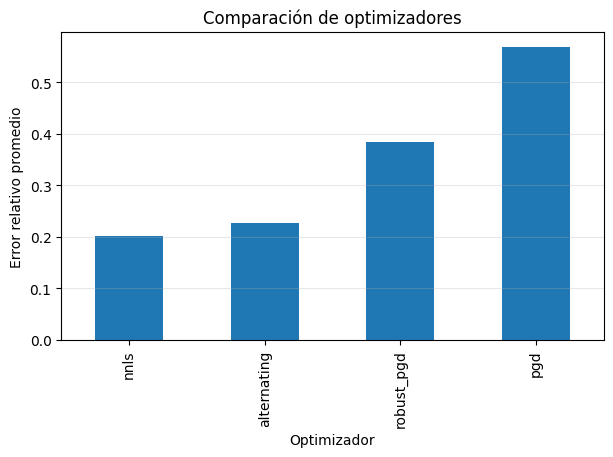

In [8]:
# 8. Gráfico optimizadores

plt.figure(figsize=(7,4))
res_opt["error_rel_promedio"].plot(kind="bar")
plt.ylabel("Error relativo promedio")
plt.xlabel("Optimizador")
plt.title("Comparación de optimizadores")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [9]:
# 9. Comparación de discretización

res_disc = (
    df_base
    .groupby("discretizacion")
    .agg(
        n_experimentos=("error_rel", "count"),
        error_rel_promedio=("error_rel", "mean"),
        error_rel_min=("error_rel", "min"),
        tiempo_promedio=("tiempo_segundos", "mean")
    )
    .sort_values("error_rel_promedio")
)

res_disc.round(4)

,n_experimentos,error_rel_promedio,error_rel_min,tiempo_promedio
discretizacion,,,,
percentiles,50,0.2473,0.1192,44.6854
interpolacion,58,0.3837,0.2162,40.7819


In [10]:
# 10. COmparación 50 vs 100

res_puntos = (
    df_base
    .groupby("n_puntos")
    .agg(
        n_experimentos=("error_rel", "count"),
        error_rel_promedio=("error_rel", "mean"),
        error_rel_min=("error_rel", "min"),
        tiempo_promedio=("tiempo_segundos", "mean")
    )
    .sort_values("error_rel_promedio")
)

res_puntos.round(4)

,n_experimentos,error_rel_promedio,error_rel_min,tiempo_promedio
n_puntos,,,,
50,58,0.3146,0.1192,41.8388
100,50,0.3275,0.1466,43.4594


In [11]:
# 11. Comparación por normalización y suavizado

res_proc = (
    df_base
    .groupby(["normalizacion", "suavizado"])
    .agg(
        n_experimentos=("error_rel", "count"),
        error_rel_promedio=("error_rel", "mean"),
        error_rel_min=("error_rel", "min"),
        tiempo_promedio=("tiempo_segundos", "mean")
    )
    .sort_values("error_rel_promedio")
)

res_proc.round(4)

,,n_experimentos,error_rel_promedio,error_rel_min,tiempo_promedio
normalizacion,suavizado,,,,
minmax,none,47,0.2370,0.1192,4.3667
zscore,savgol,61,0.3849,0.1398,72.0391


In [12]:
# 12. Comparación por inicialización

res_init = (
    df_base
    .groupby("inicializacion")
    .agg(
        n_experimentos=("error_rel", "count"),
        error_rel_promedio=("error_rel", "mean"),
        error_rel_min=("error_rel", "min"),
        tiempo_promedio=("tiempo_segundos", "mean")
    )
    .sort_values("error_rel_promedio")
)

res_init.round(4)

,n_experimentos,error_rel_promedio,error_rel_min,tiempo_promedio
inicializacion,,,,
pca,24,0.2941,0.1399,58.3711
random,61,0.3179,0.1192,29.1707
furthest_sum,23,0.3552,0.1398,61.7087


In [13]:
# 13. Analizar límite de iteraciones

df_base.groupby("optimizacion").agg(
    porcentaje_convergencia=("convergio", "mean"),
    iteraciones_promedio=("iteraciones_reales", "mean"),
    iteraciones_max=("iteraciones_reales", "max")
).round(2)

,porcentaje_convergencia,iteraciones_promedio,iteraciones_max
optimizacion,,,
alternating,0.50,73.00,100
nnls,0.91,56.09,100
pgd,0.00,100.00,100
robust_pgd,0.21,88.62,100


In [14]:
# 14. Ranking final

ranking = df_base.sort_values("error_rel")

ranking[
    [
        "discretizacion",
        "n_puntos",
        "normalizacion",
        "suavizado",
        "inicializacion",
        "optimizacion",
        "K",
        "error_rel",
        "error_fro",
        "convergio",
        "iteraciones_reales",
        "tiempo_segundos",
        "ruta_experimento"
    ]
].head(15)

,discretizacion,n_puntos,normalizacion,suavizado,inicializacion,optimizacion,K,error_rel,error_fro,convergio,iteraciones_reales,tiempo_segundos,ruta_experimento
36,percentiles,50,minmax,none,random,nnls,10,0.119200,16.126419,True,87,3.006653,resultados\experimentos\AA_13B6159A6E_rrlyrae_...
35,percentiles,50,minmax,none,random,nnls,8,0.123128,16.657794,True,48,2.053073,resultados\experimentos\AA_4694C3F4EC_rrlyrae_...
34,percentiles,50,minmax,none,random,nnls,6,0.128300,17.357501,True,66,2.572222,resultados\experimentos\AA_2BE5F899AA_rrlyrae_...
33,percentiles,50,minmax,none,random,nnls,4,0.135316,18.306683,True,80,2.476201,resultados\experimentos\AA_992965CD69_rrlyrae_...
92,percentiles,50,zscore,savgol,furthest_sum,robust_pgd,10,0.139795,30.905587,False,100,85.732035,resultados\experimentos\AA_58B4F6DAC6_rrlyrae_...
87,percentiles,50,zscore,savgol,pca,robust_pgd,10,0.139879,30.924188,False,100,81.129261,resultados\experimentos\AA_094A37D07F_rrlyrae_...
86,percentiles,50,zscore,savgol,pca,robust_pgd,8,0.143465,31.716887,False,100,79.941401,resultados\experimentos\AA_858C6A101F_rrlyrae_...
32,percentiles,50,minmax,none,random,nnls,3,0.143639,19.432649,True,37,1.012039,resultados\experimentos\AA_C532DA2030_rrlyrae_...
91,percentiles,50,zscore,savgol,furthest_sum,robust_pgd,8,0.143671,31.762422,False,100,81.941994,resultados\experimentos\AA_D56D2F00B9_rrlyrae_...
45,percentiles,100,minmax,none,random,nnls,8,0.146586,27.318962,True,46,2.029421,resultados\experimentos\AA_E79FB8B8A9_rrlyrae_...


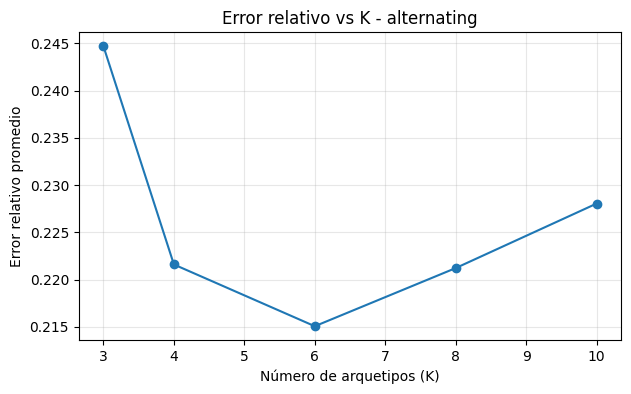

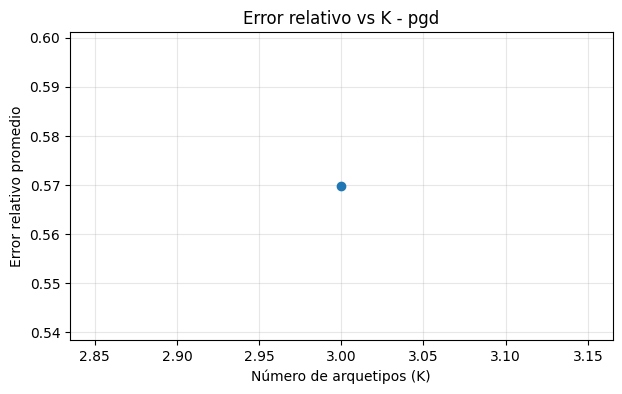

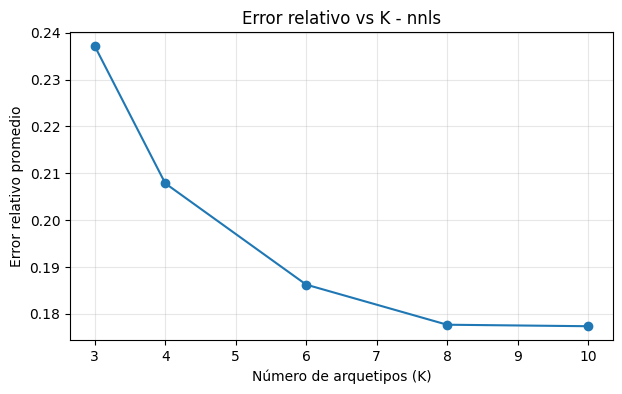

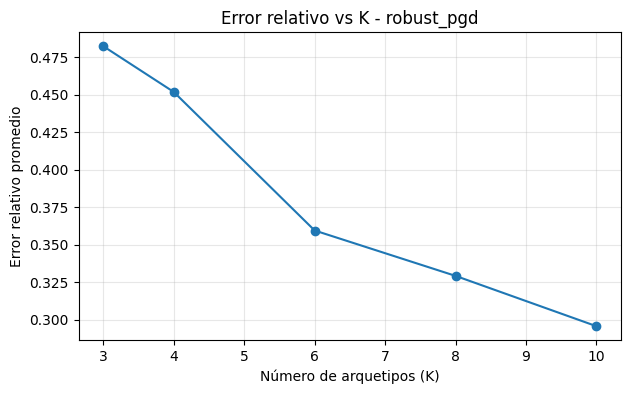

In [15]:
# 15. Método del codo por optimizador

for opt in df_base["optimizacion"].unique():

    tmp = (
        df_base[df_base["optimizacion"] == opt]
        .groupby("K")
        .agg(error_rel_promedio=("error_rel", "mean"))
        .reset_index()
        .sort_values("K")
    )

    plt.figure(figsize=(7,4))
    plt.plot(tmp["K"], tmp["error_rel_promedio"], marker="o")
    plt.xlabel("Número de arquetipos (K)")
    plt.ylabel("Error relativo promedio")
    plt.title(f"Error relativo vs K - {opt}")
    plt.grid(alpha=0.3)
    plt.show()

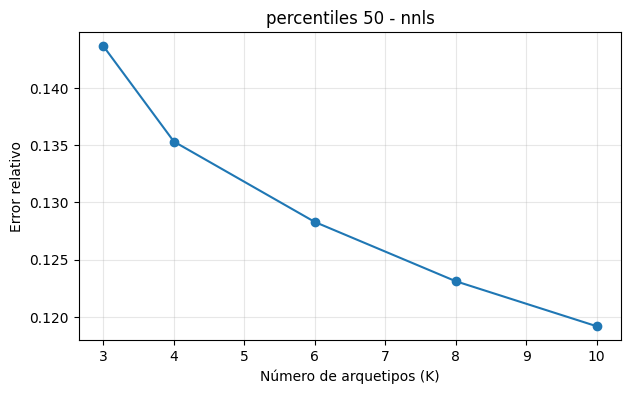

,K,error_rel,tiempo_segundos,convergio,ruta_experimento
32,3,0.143639,1.012039,True,resultados\experimentos\AA_C532DA2030_rrlyrae_...
33,4,0.135316,2.476201,True,resultados\experimentos\AA_992965CD69_rrlyrae_...
34,6,0.128300,2.572222,True,resultados\experimentos\AA_2BE5F899AA_rrlyrae_...
35,8,0.123128,2.053073,True,resultados\experimentos\AA_4694C3F4EC_rrlyrae_...
36,10,0.119200,3.006653,True,resultados\experimentos\AA_13B6159A6E_rrlyrae_...


In [16]:
# 16. Codo por configuración específica

def plot_codo_config(discretizacion, n_puntos, optimizacion, normalizacion=None, suavizado=None):

    tmp = df_base[
        (df_base["discretizacion"] == discretizacion) &
        (df_base["n_puntos"] == n_puntos) &
        (df_base["optimizacion"] == optimizacion)
    ].copy()

    if normalizacion is not None:
        tmp = tmp[tmp["normalizacion"] == normalizacion]

    if suavizado is not None:
        tmp = tmp[tmp["suavizado"] == suavizado]

    tmp = tmp.sort_values("K")

    plt.figure(figsize=(7,4))
    plt.plot(tmp["K"], tmp["error_rel"], marker="o")
    plt.xlabel("Número de arquetipos (K)")
    plt.ylabel("Error relativo")
    plt.title(f"{discretizacion} {n_puntos} - {optimizacion}")
    plt.grid(alpha=0.3)
    plt.show()

    return tmp[
        [
            "K",
            "error_rel",
            "tiempo_segundos",
            "convergio",
            "ruta_experimento"
        ]
    ]

plot_codo_config(
    discretizacion="percentiles",
    n_puntos=50,
    optimizacion="nnls"
)

In [17]:
# 17. Mejor experimento

mejor = ranking.iloc[0]

mejor[
    [
        "experiment_id",
        "modelo",
        "dataset",
        "discretizacion",
        "n_puntos",
        "normalizacion",
        "suavizado",
        "inicializacion",
        "optimizacion",
        "K",
        "error_rel",
        "error_fro",
        "tiempo_segundos",
        "ruta_experimento"
    ]
]

experiment_id                                              13B6159A6E
modelo                                                             AA
dataset                                                       rrlyrae
discretizacion                                            percentiles
n_puntos                                                           50
normalizacion                                                  minmax
suavizado                                                        none
inicializacion                                                 random
optimizacion                                                     nnls
K                                                                  10
error_rel                                                      0.1192
error_fro                                                   16.126419
tiempo_segundos                                              3.006653
ruta_experimento    resultados\experimentos\AA_13B6159A6E_rrlyrae_...
Name: 36, dtype: obj

In [20]:
from utils.comparacion import comparar_experimentos

comparar_experimentos(
    "../resultados/experimentos/AA_6AB844BEA5_rrlyrae_percentiles_100_K6",
    "../resultados/experimentos/AA_CF13F398EC_rrlyrae_percentiles_100_K6",
    indices_reconstruccion=[0, 50, 999]
)

historial_error no disponible para este experimento: AA_6AB844BEA5_rrlyrae_percentiles_100_K6
historial_error no disponible para este experimento: AA_CF13F398EC_rrlyrae_percentiles_100_K6

Resumen comparativo:
                      nombre_experimento optimizacion inicializacion  K  error_rel  error_fro convergio iteraciones_reales tiempo_segundos
AA_6AB844BEA5_rrlyrae_percentiles_100_K6         nnls         random  6   0.151397  28.215444      True                 69         3.06414
AA_CF13F398EC_rrlyrae_percentiles_100_K6   robust_pgd   furthest_sum  6   0.209491  65.034498     False                100       71.066948
Cargando dataset:
C:\Users\adanm\Documentos\Magister en Ciencia de datos (UDLA)\TESIS\experimentos\datos_discretizados\percentiles\rrlyrae_100.parquet
Submuestreo activado: 1000 estrellas
Estrellas cargadas : 1,000
Variables           : 100
Cargando dataset:
C:\Users\adanm\Documentos\Magister en Ciencia de datos (UDLA)\TESIS\experimentos\datos_discretizados\percentiles\r

C:\Users\adanm\AppData\Local\Temp\ipykernel_9296\1400238482.py:3: UserWarning: Las configuraciones de datos son distintas; se cargara X por separado.
  comparar_experimentos(


{'carpeta_comparacion': WindowsPath('C:/Users/adanm/Documentos/Magister en Ciencia de datos (UDLA)/TESIS/experimentos/resultados/comparaciones/AA_6AB844BEA5_rrlyrae_percentiles_100_K6_VS_AA_CF13F398EC_rrlyrae_percentiles_100_K6'),
 'resumen':                          nombre_experimento optimizacion inicializacion  K  \
 0  AA_6AB844BEA5_rrlyrae_percentiles_100_K6         nnls         random  6   
 1  AA_CF13F398EC_rrlyrae_percentiles_100_K6   robust_pgd   furthest_sum  6   
 
    error_rel  error_fro convergio iteraciones_reales tiempo_segundos  
 0   0.151397  28.215444      True                 69         3.06414  
 1   0.209491  65.034498     False                100       71.066948  ,
 'figuras': {'arquetipos': WindowsPath('C:/Users/adanm/Documentos/Magister en Ciencia de datos (UDLA)/TESIS/experimentos/resultados/comparaciones/AA_6AB844BEA5_rrlyrae_percentiles_100_K6_VS_AA_CF13F398EC_rrlyrae_percentiles_100_K6/arquetipos_comparacion.png'),
  'reconstrucciones': WindowsPath('C:/Use

In [21]:
cols = [
    "optimizacion", "normalizacion", "suavizado", "discretizacion",
    "n_puntos", "K", "error_rel", "convergio",
    "iteraciones_reales", "tiempo_segundos", "ruta_experimento"
]

df_base[df_base["optimizacion"].isin(["nnls", "robust_pgd"])] \
    .sort_values("error_rel")[cols] \
    .head(20)

,optimizacion,normalizacion,suavizado,discretizacion,n_puntos,K,error_rel,convergio,iteraciones_reales,tiempo_segundos,ruta_experimento
36,nnls,minmax,none,percentiles,50,10,0.119200,True,87,3.006653,resultados\experimentos\AA_13B6159A6E_rrlyrae_...
35,nnls,minmax,none,percentiles,50,8,0.123128,True,48,2.053073,resultados\experimentos\AA_4694C3F4EC_rrlyrae_...
34,nnls,minmax,none,percentiles,50,6,0.128300,True,66,2.572222,resultados\experimentos\AA_2BE5F899AA_rrlyrae_...
33,nnls,minmax,none,percentiles,50,4,0.135316,True,80,2.476201,resultados\experimentos\AA_992965CD69_rrlyrae_...
92,robust_pgd,zscore,savgol,percentiles,50,10,0.139795,False,100,85.732035,resultados\experimentos\AA_58B4F6DAC6_rrlyrae_...
87,robust_pgd,zscore,savgol,percentiles,50,10,0.139879,False,100,81.129261,resultados\experimentos\AA_094A37D07F_rrlyrae_...
86,robust_pgd,zscore,savgol,percentiles,50,8,0.143465,False,100,79.941401,resultados\experimentos\AA_858C6A101F_rrlyrae_...
32,nnls,minmax,none,percentiles,50,3,0.143639,True,37,1.012039,resultados\experimentos\AA_C532DA2030_rrlyrae_...
91,robust_pgd,zscore,savgol,percentiles,50,8,0.143671,False,100,81.941994,resultados\experimentos\AA_D56D2F00B9_rrlyrae_...
45,nnls,minmax,none,percentiles,100,8,0.146586,True,46,2.029421,resultados\experimentos\AA_E79FB8B8A9_rrlyrae_...
